# Rubin On-Axis Donuts with Camera and M2 Both Pistoned 4 mm (v1)

**Author:** Aaron Roodman (with Claude)
**Date Created:** 2026-10-09
**Last Modified:** 2026-10-09
**Status:** Complete
**Keywords:** donut, defocus, camera hexapod, M2 hexapod, ray tracing, Kolmogorov, seeing, Rubin

## Description

Geometric ray-traced donuts for the Rubin design prescription (`LSST_r.yaml`, 622 nm,
on axis), with the camera hexapod and the M2 hexapod both pistoned 4 mm in the same
direction along global z: −4 mm for the intra-focal donut and +4 mm for the
extra-focal donut. Each hexapod alone gives roughly 4 mm of equivalent focal-plane
defocus, so together they give a donut of about 8 mm equivalent defocus.

1. Ray tracing: 2×10⁸ rays drawn uniformly over the entrance pupil, binned into
   10 µm pixels (the geometric image).
2. Seeing: the geometric image convolved with a Kolmogorov kernel of 0.7″ full width
   at half maximum (FWHM), scaled by the plate scale of each defocused configuration.
3. Comparison of the intra- and extra-focal images, radial profiles, donut radii and
   transverse-aberration Zernike coefficients.

**Output:** figures and a `.npz` of the stamps in `optics/output/fresnel/`.

**Based on:** `optics/docs/studies/fresnel_donuts.md`,
`optics_fresnel_rubin_seeing_v1.ipynb`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-10-09 | Aaron Roodman (with Claude) | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Configurations](#configs)
5. [Geometric donuts](#geometric)
6. [Donuts with 0.7″ Kolmogorov seeing](#seeing)
7. [Radial profiles and intra − extra](#profiles)
8. [Radii and Zernike coefficients](#zernikes)
9. [Conclusions](#conclusions)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================
prescription = 'LSST_r.yaml'   # batoid design prescription, r band
wavelength = 622e-9            # m
piston = 4e-3                  # m, camera and M2 piston magnitude (same sign)
seeing_fwhm = 0.7              # arcsec, Kolmogorov FWHM

n_rays = 200_000_000           # rays per donut
batch = 4_000_000              # rays per trace batch
pixel = 10e-6                  # m, LSSTCam pixel
oversample = 5                 # sub-pixels per pixel for the convolution
npix = 740                     # pixels per stamp side (7.4 mm)
kernel_npix = 301              # kernel samples per side at pixel/oversample

r_max_um = 3800.0              # um, outer radius of the radial profiles
dr_um = 5.0                    # um, radial-profile annulus width
output_date = '20261009'

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))        # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))
for _d in sorted((_TOPIC / 'code').glob('*/')):
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))
from common.utils import setup_plotting

import fresnel_donut as fd     # imports finufft before batoid (OpenMP order)
import donut_seeing as ds
import batoid
import galsim

setup_plotting()
output_dir = _TOPIC / 'output' / 'fresnel'
output_dir.mkdir(parents=True, exist_ok=True)
print('batoid', batoid.__version__, '| galsim', galsim.__version__)

batoid 0.8.1 | galsim 2.8.5


<a id='functions'></a>
## Helper Functions

In [3]:
r_edges_um = np.arange(0, r_max_um + 1e-9, dr_um)
r_centers_um = 0.5 * (r_edges_um[1:] + r_edges_um[:-1])


def focal_side(optic):
    """'intra' if the image is upright (detector before focus), else 'extra'.

    A ray from the top of the entrance pupil lands above the chief ray before
    focus and below it after focus.
    """
    ray = batoid.RayVector.fromStop(0.0, 3.5, optic=optic, wavelength=wavelength,
                                    dirCos=fd.dircos(0.0, 0.0))
    optic.trace(ray)
    c = fd.chief_ray_point(optic, wavelength)
    return 'intra' if ray.y[0] - c[1] > 0 else 'extra'


def trace_donut(optic, center, seed=1):
    """Accumulate a geometric donut in batches.

    Returns the image binned at pixel/oversample (unit total flux, [y, x]), the
    radial ray counts in `r_edges_um`, and the 0.01 and 99.99 percentile ray
    radii (m) from the first batch.
    """
    rng = np.random.default_rng(seed)
    half = optic.pupilSize / 2
    n_fine = npix * oversample
    edges = (np.arange(n_fine + 1) - n_fine / 2) * pixel / oversample
    img = np.zeros((n_fine, n_fine))
    counts = np.zeros(len(r_edges_um) - 1)
    radii = None
    remaining = n_rays
    while remaining > 0:
        n = min(batch, remaining)
        u = rng.uniform(-half, half, n)
        v = rng.uniform(-half, half, n)
        rv = batoid.RayVector.fromStop(u, v, optic=optic, wavelength=wavelength,
                                       dirCos=fd.dircos(0.0, 0.0))
        optic.trace(rv)
        ok = ~rv.vignetted & ~rv.failed
        dx = rv.x[ok] - center[0]
        dy = rv.y[ok] - center[1]
        h, _, _ = np.histogram2d(dy, dx, bins=[edges, edges])
        img += h
        r = np.hypot(dx, dy)
        counts += np.histogram(r * 1e6, r_edges_um)[0]
        if radii is None:
            radii = np.percentile(r, [0.01, 99.99])
        remaining -= n
    return img / img.sum(), counts, radii


def ray_profile(counts):
    """Surface brightness from radial ray counts, int E 2 pi r dr = 1 (1/um^2)."""
    area = np.pi * np.diff(r_edges_um**2)
    return counts / area / counts.sum()


def pixel_profile(image, scale_um):
    """Azimuthal mean of a centred stamp [y, x], normalised to int E 2 pi r dr = 1."""
    n = image.shape[0]
    c = (np.arange(n) - (n - 1) / 2) * scale_um
    X, Y = np.meshgrid(c, c)
    r = np.hypot(X, Y).ravel()
    tot, _ = np.histogram(r, r_edges_um, weights=image.ravel())
    cnt, _ = np.histogram(r, r_edges_um)
    prof = tot / np.maximum(cnt, 1) / scale_um**2
    return prof / np.sum(prof * 2 * np.pi * r_centers_um * dr_um)

<a id='configs'></a>
## 4. Configurations

Camera and M2 are pistoned by the same amount along global z. With the batoid Rubin
prescriptions, −4 mm on both is intra-focal and +4 mm on both is extra-focal; the
focal side is checked from the image orientation (a ray from the top of the pupil
lands above the chief ray only before focus).

In [4]:
telescope = batoid.Optic.fromYaml(prescription)
optics = {}
for dz in (-piston, piston):
    o = fd.shift_camera(telescope, dz).withGloballyShiftedOptic('M2', [0.0, 0.0, dz])
    optics[focal_side(o)] = o
    print(f"camera and M2 {dz*1e3:+.0f} mm: {focal_side(o)}")
assert set(optics) == {'intra', 'extra'}
optics = {k: optics[k] for k in ('intra', 'extra')}
plate = {k: ds.plate_scale(o, wavelength) for k, o in optics.items()}
for k in optics:
    print(f"{k}: plate scale {plate[k]:.4f} m/rad "
          f"({plate[k] * ds.ARCSEC * 1e6:.3f} um/arcsec)")

camera and M2 -4 mm: intra
camera and M2 +4 mm: extra
intra: plate scale 10.3192 m/rad (50.029 um/arcsec)
extra: plate scale 10.3006 m/rad (49.939 um/arcsec)


<a id='geometric'></a>
## 5. Geometric donuts

Rays are binned at 2 µm (pixel/5) around the chief-ray point; summing 5×5 blocks
gives 10 µm pixels.

In [5]:
res = {}
for k, o in optics.items():
    t0 = time.perf_counter()
    center = fd.chief_ray_point(o, wavelength)
    fine, counts, radii = trace_donut(o, center)
    res[k] = dict(center=center, fine=fine, geo=ds.rebin(fine, oversample),
                  prof_geo=ray_profile(counts), r_in=radii[0], r_out=radii[1],
                  n=counts.sum())
    print(f"{k}: {res[k]['n']:.3e} rays kept, {time.perf_counter()-t0:.0f} s")

intra: 9.824e+07 rays kept, 240 s


extra: 9.824e+07 rays kept, 235 s


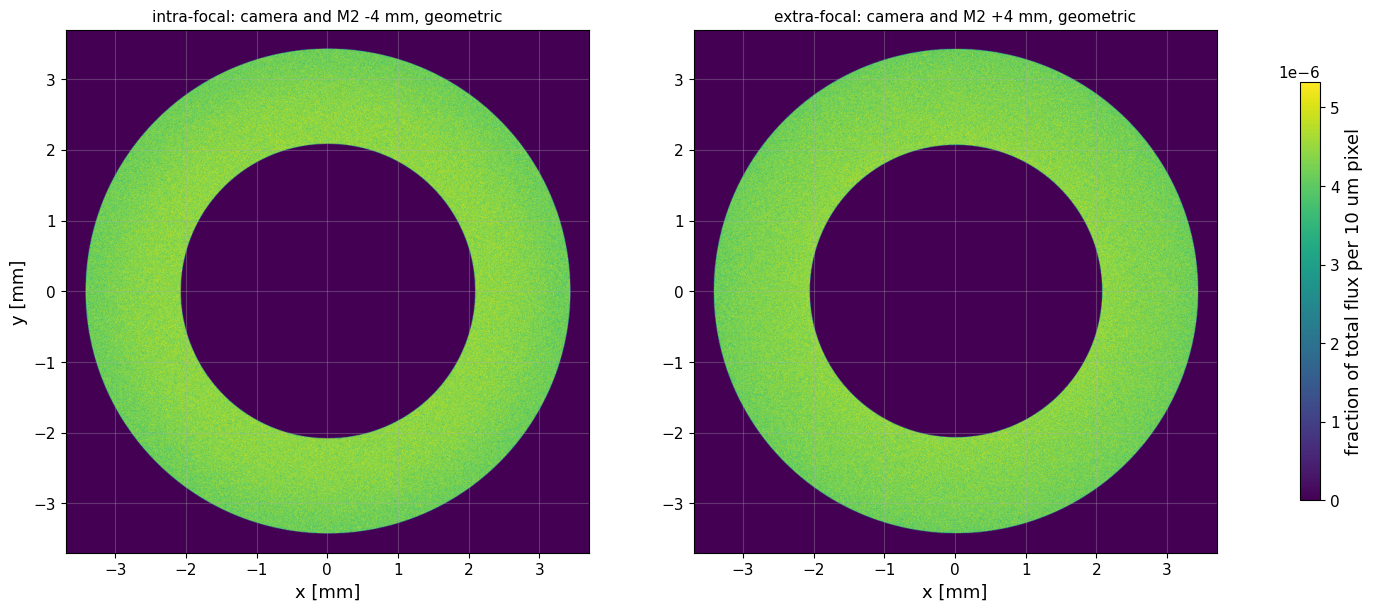

In [6]:
extent = np.array([-1, 1, -1, 1]) * npix * pixel * 1e3 / 2   # mm


def show_pair(key, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    vmax = max(r[key].max() for r in res.values())
    for ax, (k, r) in zip(axes, res.items()):
        im = ax.imshow(r[key], origin='lower', extent=extent, vmin=0, vmax=vmax,
                       cmap='viridis')
        ax.set_title(f'{k}-focal: camera and M2 {"-" if k == "intra" else "+"}4 mm, '
                     f'{title}', fontsize=11)
        ax.set_xlabel('x [mm]')
    axes[0].set_ylabel('y [mm]')
    fig.colorbar(im, ax=axes, shrink=0.8,
                 label='fraction of total flux per 10 um pixel')
    fig.savefig(output_dir / fname, dpi=120, bbox_inches='tight')


show_pair('geo', 'geometric', f'optics_fresnel_hexapods4mm_geometric_{output_date}.png')

<a id='seeing'></a>
## 6. Donuts with 0.7″ Kolmogorov seeing

The Kolmogorov kernel (`galsim.Kolmogorov`, FWHM 0.7″) is drawn at 2 µm on the
detector using the plate scale of each configuration, convolved with the 2 µm
geometric image, and summed into 10 µm pixels. For a long exposure, seeing and optics
are separable (`optics_fresnel_rubin_seeing_v1.ipynb`).

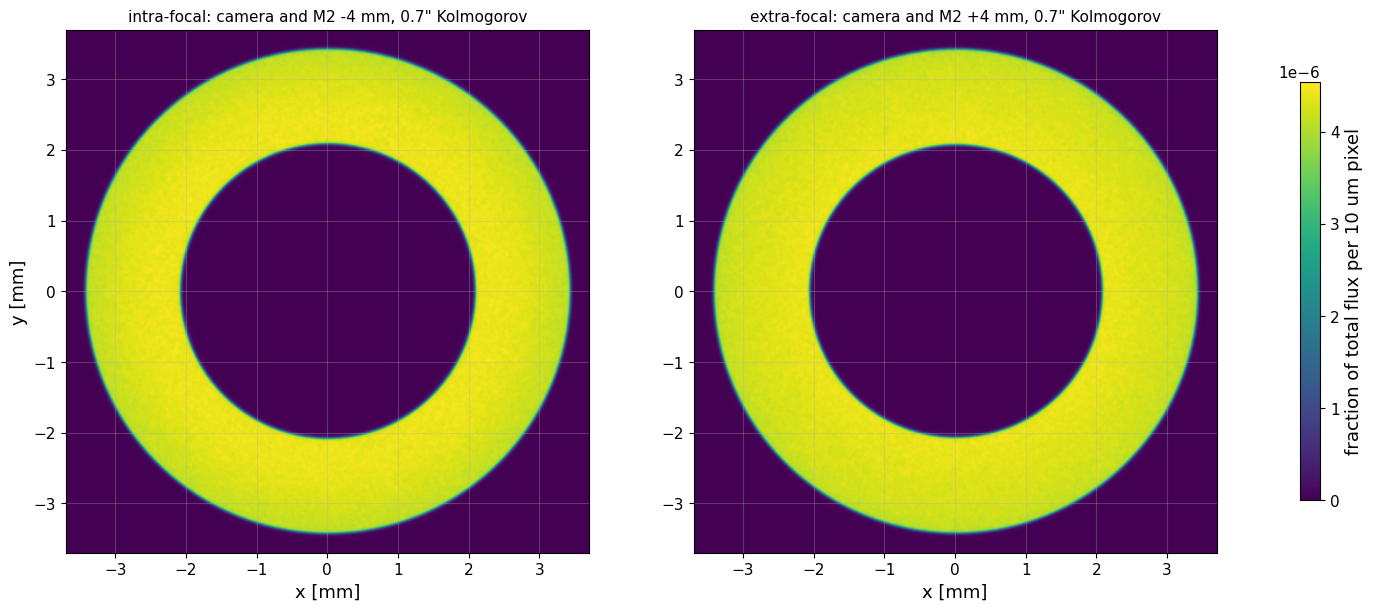

In [7]:
psf = galsim.Kolmogorov(fwhm=seeing_fwhm)
for k, r in res.items():
    kernel = ds.psf_kernel(psf, pixel / oversample, plate[k], npix=kernel_npix)
    r['see'] = ds.rebin(ds.smear(r['fine'], kernel), oversample)

show_pair('see', '0.7" Kolmogorov', f'optics_fresnel_hexapods4mm_seeing_{output_date}.png')

np.savez_compressed(
    output_dir / f'optics_fresnel_hexapods4mm_stamps_{output_date}.npz',
    labels=np.array(list(res)), pixel_m=pixel, seeing_fwhm_arcsec=seeing_fwhm,
    piston_m=piston,
    geometric=np.array([r['geo'] for r in res.values()]),
    seeing=np.array([r['see'] for r in res.values()]))

<a id='profiles'></a>
## 7. Radial profiles and intra − extra

Geometric profiles come from the ray radii in 5 µm annuli; the seeing profiles are
azimuthal means of the 10 µm pixel stamps. Both are normalised to
∫ E 2πr dr = 1 (units 1/µm²). The right panel is the intra − extra difference of the
seeing stamps (the on-axis donut is circular, so the image inversion between the two
sides does not matter), as a fraction of the extra-focal peak pixel.

sum |intra - extra| (seeing, 10 um pixels) = 0.0218 of total flux


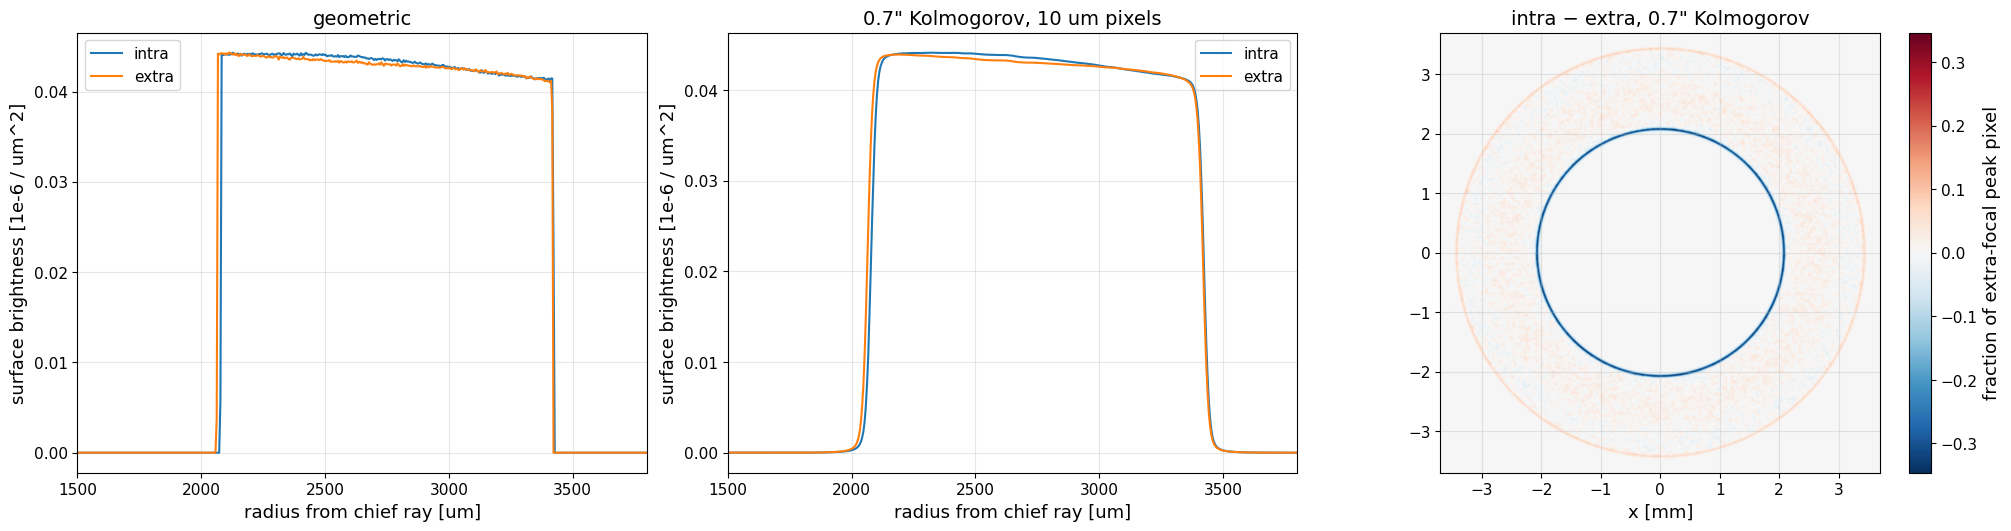

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.2))
for k, r in res.items():
    col = 'C0' if k == 'intra' else 'C1'
    r['prof_see'] = pixel_profile(r['see'], pixel * 1e6)
    axes[0].plot(r_centers_um, r['prof_geo'] * 1e6, color=col, label=k)
    axes[1].plot(r_centers_um, r['prof_see'] * 1e6, color=col, label=k)
axes[0].set_title('geometric')
axes[1].set_title('0.7" Kolmogorov, 10 um pixels')
for ax in axes[:2]:
    ax.set_xlabel('radius from chief ray [um]')
    ax.set_ylabel('surface brightness [1e-6 / um^2]')
    ax.set_xlim(1500, 3800)
    ax.legend()
d = (res['intra']['see'] - res['extra']['see']) / res['extra']['see'].max()
lim = np.max(np.abs(d))
im = axes[2].imshow(d, origin='lower', extent=extent, cmap='RdBu_r',
                    vmin=-lim, vmax=lim)
axes[2].set_title('intra − extra, 0.7" Kolmogorov')
axes[2].set_xlabel('x [mm]')
fig.colorbar(im, ax=axes[2], label='fraction of extra-focal peak pixel')
fig.savefig(output_dir / f'optics_fresnel_hexapods4mm_profiles_{output_date}.png',
            dpi=120, bbox_inches='tight')
print(f"sum |intra - extra| (seeing, 10 um pixels) = "
      f"{np.abs(res['intra']['see'] - res['extra']['see']).sum():.4f} of total flux")

<a id='zernikes'></a>
## 8. Radii and Zernike coefficients

Inner and outer geometric radii are the 0.01 and 99.99 percentiles of the ray radius
(first batch of rays). The Zernike coefficients are `batoid.analysis.zernikeTA` of
each defocused optic (annular Noll, obscuration 0.612, chief-ray referenced, jmax 66),
in µm of wavefront.

In [9]:
print(f"{'donut':6s} {'r_in [um]':>10s} {'r_out [um]':>10s} {'r_in/r_out':>10s} "
      f"{'Z4 [um]':>9s} {'Z11 [um]':>9s} {'Z22 [um]':>9s} {'Z37 [um]':>9s}")
for k, o in optics.items():
    z = ds.reference_zernikes(o, wavelength, jmax=66) * 1e6
    r = res[k]
    r['z'] = z
    print(f"{k:6s} {r['r_in']*1e6:10.1f} {r['r_out']*1e6:10.1f} "
          f"{r['r_in']/r['r_out']:10.4f} {z[4]:9.3f} {z[11]:9.4f} {z[22]:9.4f} "
          f"{z[37]:9.4f}")

donut   r_in [um] r_out [um] r_in/r_out   Z4 [um]  Z11 [um]  Z22 [um]  Z37 [um]
intra      2079.5     3422.6     0.6076  -124.543   -0.1160   -0.0343   -0.0004
extra      2064.7     3419.5     0.6038   124.250    0.2160    0.0037    0.0002


<a id='conclusions'></a>
## 9. Conclusions

Monochromatic (622 nm), on axis, design prescription, camera and M2 both pistoned
∓4 mm. Numbers are from this run.

- **Equivalent defocus.** Z4 = −124.5 µm (intra) and +124.3 µm (extra) of wavefront;
  the outer donut radius is 3.42 mm on both sides.
- **The two sides differ in inner radius.** The geometric inner radius is 2079.5 µm
  intra-focal and 2064.7 µm extra-focal, a 14.8 µm difference (about 1.5 pixels);
  the outer radii differ by only 3.1 µm. The inner/outer radius ratio is 0.6076
  intra and 0.6038 extra (dimensionless).
- **Defocus-induced spherical aberration.** Z11 = −0.116 µm intra and +0.216 µm
  extra (antisymmetric part 0.166 µm, symmetric part +0.050 µm of wavefront);
  Z22 = −0.034 and +0.004 µm.
- **Intra − extra.** With 0.7″ Kolmogorov seeing the stamps differ by
  Σ|Δ| = 2.2% of total flux. The difference map is dominated by the ring at the inner
  edge from the 14.8 µm radius offset; the interior shows shot noise (about 430 rays
  per 10 µm pixel, so about 5% rms per pixel before seeing).
- **Surface brightness** falls by about 6% from the inner to the outer edge on both
  sides, from the non-linear map between pupil and detector in the f/1.23 beam.

In [10]:
for k, r in res.items():
    print(f"{k}: peak pixel geometric {r['geo'].max():.2e}, with seeing "
          f"{r['see'].max():.2e} (fraction of total flux)")

intra: peak pixel geometric 5.32e-06, with seeing 4.54e-06 (fraction of total flux)
extra: peak pixel geometric 5.24e-06, with seeing 4.51e-06 (fraction of total flux)
